# Predicting Steroid Receptor Selectivity

Multi-task graph neural network for ERα / ERβ / AR / PR / GR / MR binding prediction.

See `README.md` for background on the NR3 subfamily, the masked-loss trick, and expected results.

## 1. Imports

In [1]:
import gc
import json
import urllib.error
import urllib.request
from pathlib import Path

In [2]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from chembl_webresource_client.new_client import new_client
from matplotlib.lines import Line2D
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

RDLogger.DisableLog("rdApp.*")  # silence RDKit parse warnings

In [3]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
print("device:", device)

device: mps


## 2. Pull bioactivity data from ChEMBL

The six human steroid receptors:

| Receptor | ChEMBL ID  | Subfamily |
|----------|------------|-----------|
| ERα      | CHEMBL206  | NR3A1     |
| ERβ      | CHEMBL242  | NR3A2     |
| AR       | CHEMBL1871 | NR3C4     |
| PR       | CHEMBL208  | NR3C3     |
| GR       | CHEMBL2034 | NR3C1     |
| MR       | CHEMBL1994 | NR3C2     |

Each target is cached separately to parquet, so a network interruption only loses one. The first full run takes ~15 minutes.

### Key concepts:

**SMILES (Simplified Molecular Input Line Entry System)**  
A text format for describing molecular structure as a string. Atoms are letters, bonds are implied by adjacency or written with - = #, branches are in parentheses, rings are marked with matching numbers.  
Examples:  

CCO — ethanol (carbon-carbon-oxygen, hydrogens implicit)  
c1ccccc1 — benzene (lowercase = aromatic, the 1s close the ring)  
CC(=O)O — acetic acid (the (=O) is a branch with a double bond to oxygen)  
C[C@H](N)C(=O)O — L-alanine (the [C@H] specifies stereochemistry)  

The big advantage: a molecule becomes a single string you can store in a CSV, search with regex, or feed to a model. RDKit parses SMILES into a graph object with Chem.MolFromSmiles(smi), which is the first step in everything we did. The same molecule can have multiple valid SMILES, but tools can produce a "canonical" SMILES — a unique, deterministic version useful for deduplication.  

**pActivity**  
A log-transformed potency value. Calculated as:  
pActivity = -log10(concentration_in_molar)  
So a binding affinity of 1 µM (= 10⁻⁶ M) becomes pActivity = 6; 1 nM becomes pActivity = 9; 1 mM becomes pActivity = 3. 

Why use the log instead of the raw value:  

Drug-like potencies span huge ranges — from millimolar (weak) to picomolar (very strong), that's 9 orders of magnitude. Plotting or modeling raw concentrations is impossible. Logs compress this into a friendly 3–12 range.  
Equal log differences feel equal biologically. Moving from 1 µM to 100 nM (10× improvement) is the same effort as moving from 100 nM to 10 nM. The log scale reflects that.  
Higher = more potent, which is more intuitive than "lower IC50 = better."  

When ChEMBL gives you an IC50 of 50 nM, that's -log10(50e-9) = 7.3. Anything ≥ 6 is what we called a "binder" (i.e., ≤ 1 µM affinity) — a standard, if coarse, cheminformatics cutoff.  
The "p" prefix comes from chemistry's general convention (same as pH, pKa, pKi). You'll see pIC50, pKi, pEC50 — all the same idea applied to different assay readouts.

In [4]:
RECEPTORS = {
    "ERa": "CHEMBL206",
    "ERb": "CHEMBL242",
    "AR": "CHEMBL1871",
    "PR": "CHEMBL208",
    "GR": "CHEMBL2034",
    "MR": "CHEMBL1994",
}
TARGETS = list(RECEPTORS.keys())  # canonical order

In [5]:
def fetch_activities(target_chembl_id, target_name):
    activity = new_client.activity
    res = activity.filter(
        target_chembl_id=target_chembl_id,
        standard_type_in=["IC50", "Ki", "Kd", "EC50"],
        standard_units="nM",
    ).only(["canonical_smiles", "standard_value", "standard_type"])
    df = pd.DataFrame(res)
    df["target"] = target_name
    df = df.dropna(subset=["canonical_smiles", "standard_value"])
    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
    df = df.dropna(subset=["standard_value"])
    df = df[df["standard_value"] > 0]
    df["pActivity"] = -np.log10(df["standard_value"] * 1e-9)
    return df[["canonical_smiles", "pActivity", "target"]]

In [6]:
CACHE_DIR = Path("chembl_cache")
CACHE_DIR.mkdir(exist_ok=True)

In [7]:
dfs = []
for name, cid in RECEPTORS.items():
    cache = CACHE_DIR / f"{name}.parquet"
    if cache.exists():
        d = pd.read_parquet(cache)
        print(f"  {name}: loaded {len(d)} from cache")
    else:
        print(f"  {name}: fetching from ChEMBL...")
        d = fetch_activities(cid, name)
        d.to_parquet(cache)
        print(f"  {name}: fetched {len(d)}, cached")
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(f"\ntotal: {len(df)} measurements")

  ERa: loaded 8788 from cache
  ERb: loaded 4153 from cache
  AR: loaded 6416 from cache
  PR: loaded 3652 from cache
  GR: loaded 7268 from cache
  MR: loaded 1609 from cache

total: 31886 measurements


In [8]:
df.head(n=3)

,canonical_smiles,pActivity,target
0,Oc1ccc2c(c1)S[C@H](C1CCCC1)[C@H](c1ccc(OCCN3CC...,8.602060,ERa
1,Oc1ccc2c(c1)S[C@H](C1CCCCCC1)[C@H](c1ccc(OCCN3...,8.124939,ERa
2,Oc1ccc([C@H]2Sc3cc(O)ccc3O[C@H]2c2ccc(OCCN3CCC...,8.508638,ERa


Distribution of binding affinities. The red line marks the binder threshold (1 µM, i.e. pActivity = 6).

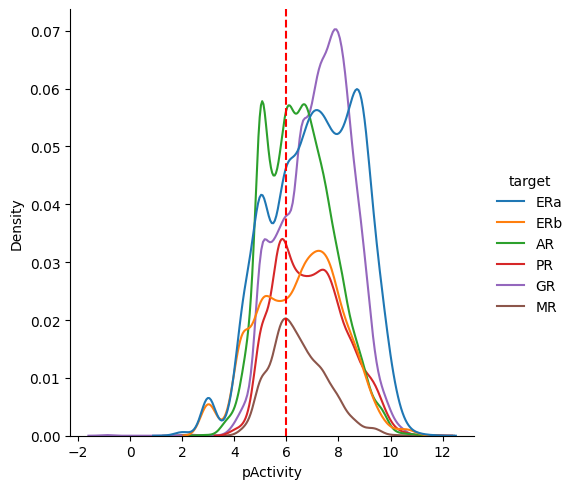

In [9]:
sns.displot(data=df, x="pActivity", kind="kde", hue="target")
plt.axvline(6, 0, 1, color="red", linestyle="--");

## 3. Build per-molecule label matrix

Threshold pActivity ≥ 6 (≤ 1 µM) for "binder". Aggregate to one row per (SMILES, receptor); `-1` marks "no measurement".

In [10]:
df["binder"] = (df["pActivity"] >= 6).astype(int)
agg = (
    df.groupby(["canonical_smiles", "target"])["binder"].max().unstack(fill_value=-1).reset_index()
)

# ensure all six columns exist in canonical order
for t in TARGETS:
    if t not in agg.columns:
        agg[t] = -1
agg = agg[["canonical_smiles"] + TARGETS]

print(f"{len(agg)} unique molecules")
print("\nlabel coverage:")
for t in TARGETS:
    n_meas = (agg[t] != -1).sum()
    n_pos = (agg[t] == 1).sum()
    print(f"  {t:4s}: {n_meas:5d} measured  ({n_pos:4d} binders, {n_pos / max(n_meas, 1):.0%})")

# how filled is the label matrix overall?
total_cells = len(agg) * len(TARGETS)
filled_cells = sum((agg[t] != -1).sum() for t in TARGETS)
print(f"\nlabel matrix fill rate: {filled_cells}/{total_cells} = {filled_cells / total_cells:.1%}")

13168 unique molecules

label coverage:
  ERa :  5118 measured  (3409 binders, 67%)
  ERb :  2802 measured  (1775 binders, 63%)
  AR  :  3426 measured  (2154 binders, 63%)
  PR  :  2341 measured  (1659 binders, 71%)
  GR  :  3674 measured  (2954 binders, 80%)
  MR  :  1236 measured  ( 776 binders, 63%)

label matrix fill rate: 18597/79008 = 23.5%


In [11]:
agg.head()

target,canonical_smiles,ERa,ERb,AR,PR,GR,MR
0,B.CP(c1ccccc1)c1ccc(O)cc1,0,0,-1,-1,-1,-1
1,B.Oc1ccc(P(c2ccccc2)c2ccccc2)cc1,0,0,-1,-1,-1,-1
2,Br.C=CCOC(C)C1=CC(C)(C)Nc2ccc(-c3cc(F)ccc3OC)cc21,0,-1,-1,1,1,0
3,Br.CCN(CC)CCc1c(C)[nH]c(C(=O)OCc2ccccc2)c1C,-1,1,-1,-1,-1,-1
4,BrC1=CN2NC(c3cc4ccccc4n3Cc3ccccc3)=NC2N=C1,1,-1,-1,-1,-1,-1


## 4. Define canonical reference ligands

We test the trained model on three categories of well-characterized molecules:

**Endogenous physiological ligands** — the natural hormones that define each receptor:
- *estradiol* → ERα, ERβ
- *testosterone*, *DHT* → AR
- *progesterone* → PR
- *cortisol* → GR (and MR — cortisol binds MR strongly; in vivo selectivity comes from 11β-HSD2, not the receptor)
- *aldosterone* → MR

**Synthetic agonist (pharmacological tool)**:
- *dexamethasone* → selective GR agonist; tests whether the model can identify GR-specific binding without the MR cross-reactivity that complicates cortisol

**Synthetic antagonists (pharmacological tools)**:
- *spironolactone* → MR antagonist with known clinical AR/PR cross-reactivity (causes gynecomastia)
- *eplerenone* → more selective MR antagonist; tests whether the model can distinguish two structurally similar molecules with different selectivity profiles

The mix is deliberate: endogenous ligands test recall of textbook biology, while synthetic tools test selectivity and known cross-reactivity patterns.

These are the molecules we will use to sanity-check the model after training. We fetch their SMILES directly from PubChem using verified CIDs — this is more reproducible than name-based lookup (which can return salts, esters, or wrong stereoisomers) and more reliable than hardcoded SMILES (which can contain transcription errors).

The first run hits the PubChem API; subsequent runs use a local JSON cache.

In [12]:
# Fetch canonical ligand SMILES from PubChem using verified CIDs.
# Using CIDs (not name search) avoids ambiguity between salts, esters,
# hydrates, and stereoisomers. The result is cached locally so reruns
# work offline.

CANONICAL_LIGAND_CIDS = {
    "estradiol": 5757,  # Endogenous ERα, ERβ (=17β-estradiol)
    "DHT": 10635,  # (=5α-dihydrotestosterone)
    "testosterone": 6013,  # Endogenous AR
    "progesterone": 5994,  # Endogenous PR
    "cortisol": 5754,  # Endogenous GR (and MR) (= hydrocortisone)
    "aldosterone": 5839,  # Endogenous MR
    "dexamethasone": 5743,  # Synthetic agonist (GR), without MR cross reactivity
    "spironolactone": 5833,  # Synthetic antagonists (MR), with AR/PR cross-reactivity
    "eplerenone": 150310,  # Synthetic antagonists (MR)
}

CANONICAL_LIGAND_CACHE = Path("canonical_ligand_smiles.json")


def fetch_smiles_from_pubchem(cid, timeout=30):
    url = (
        f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/IsomericSMILES/JSON"
    )
    with urllib.request.urlopen(url, timeout=timeout) as resp:
        data = json.loads(resp.read().decode())
    return data["PropertyTable"]["Properties"][0]["SMILES"]


if CANONICAL_LIGAND_CACHE.exists():
    canonical_ligand_dict = json.loads(CANONICAL_LIGAND_CACHE.read_text())
    print(f"loaded {len(canonical_ligand_dict)} canonical SMILES from cache")
else:
    canonical_ligand_dict = {}
    for name, cid in CANONICAL_LIGAND_CIDS.items():
        try:
            canonical_ligand_dict[name] = fetch_smiles_from_pubchem(cid)
            print(f"  {name:16s}  CID {cid:6d}  ✓")
        except (urllib.error.URLError, KeyError) as e:
            print(f"  {name:16s}  CID {cid:6d}  FAILED: {e}")
    CANONICAL_LIGAND_CACHE.write_text(json.dumps(canonical_ligand_dict, indent=2))
    print(f"\ncached {len(canonical_ligand_dict)} SMILES to {CANONICAL_LIGAND_CACHE}")

# verify each parses as a valid molecule
for name, smile in canonical_ligand_dict.items():
    mol = Chem.MolFromSmiles(smile)
    status = "ok" if mol and mol.GetNumAtoms() > 0 else "FAILED to parse"
    print(f"  {name:16s}  ({mol.GetNumAtoms() if mol else '?'} atoms)  {status} {smile}")

loaded 9 canonical SMILES from cache
  estradiol         (20 atoms)  ok C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3C=CC(=C4)O
  DHT               (21 atoms)  ok C[C@]12CCC(=O)C[C@@H]1CC[C@@H]3[C@@H]2CC[C@]4([C@H]3CC[C@@H]4O)C
  testosterone      (21 atoms)  ok C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=CC(=O)CC[C@]34C
  progesterone      (23 atoms)  ok CC(=O)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]3[C@H]2CCC4=CC(=O)CC[C@]34C)C
  cortisol          (26 atoms)  ok C[C@]12CCC(=O)C=C1CC[C@@H]3[C@@H]2[C@H](C[C@]4([C@H]3CC[C@@]4(C(=O)CO)O)C)O
  aldosterone       (26 atoms)  ok C[C@]12CCC(=O)C=C1CC[C@@H]3[C@@H]2[C@H](C[C@]4([C@H]3CC[C@@H]4C(=O)CO)C=O)O
  dexamethasone     (28 atoms)  ok C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@@]4([C@]3([C@H](C[C@@]2([C@]1(C(=O)CO)O)C)O)F)C
  spironolactone    (29 atoms)  ok CC(=O)S[C@@H]1CC2=CC(=O)CC[C@@]2([C@@H]3[C@@H]1[C@@H]4CC[C@]5([C@]4(CC3)C)CCC(=O)O5)C
  eplerenone        (30 atoms)  ok C[C@]12CCC(=O)C=C1C[C@H](C3[C@]24C(O4)C[C@]5([C@H]3CC[C@@]56CCC(=O)O6)C)C(=O

## 5. Remove close analogs of canonical ligands

To make it a real test of generalisation rather than a memorisation check, we remove from the training data any molecule with Tanimoto similarity ≥ 0.7 to any canonical ligand (*). This means estradiol, cortisol, etc. and their close neighbors will not be seen during training, so predictions on them are genuinely out-of-sample.

(*) Tanimoto similarity measures how similar two molecules are, from 0 (nothing in common) to 1 (identical).

**Why this matters.** ChEMBL contains the canonical ligands themselves and many close analogs. With a random split, a model that simply memorises its training data will appear to predict canonical ligand binding correctly. By removing the neighborhood explicitly, we force the model to generalise from chemistry it has actually never seen.

In [13]:
SIMILARITY_THRESHOLD = 0.7  # anything more similar to a canonical ligand gets removed


def fp(smi):
    mol = Chem.MolFromSmiles(smi)
    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048) if mol else None


canonical_fps = {name: fp(smi) for name, smi in canonical_ligand_dict.items()}
canonical_fps = {n: f for n, f in canonical_fps.items() if f is not None}


def max_similarity_to_canonical(smi):
    q = fp(smi)
    if q is None:
        return 0.0
    sims = [DataStructs.TanimotoSimilarity(q, cf) for cf in canonical_fps.values()]
    return max(sims) if sims else 0.0


print("computing Tanimoto similarities to canonical ligands...")
agg["max_sim_canonical"] = agg["canonical_smiles"].apply(max_similarity_to_canonical)

n_before = len(agg)
removed = agg[agg["max_sim_canonical"] >= SIMILARITY_THRESHOLD].copy()
agg_clean = agg[agg["max_sim_canonical"] < SIMILARITY_THRESHOLD].reset_index(drop=True)
n_after = len(agg_clean)

print(
    f"removed {n_before - n_after} molecules (Tanimoto ≥ {SIMILARITY_THRESHOLD} to a canonical ligand)"
)
print(f"kept {n_after} molecules for training/val/test")


def closest_canonical(smi):
    q = fp(smi)
    if q is None:
        return ("?", 0.0)
    sims = {n: DataStructs.TanimotoSimilarity(q, cf) for n, cf in canonical_fps.items()}
    best = max(sims, key=sims.get)
    return (best, sims[best])


removed["closest"] = removed["canonical_smiles"].apply(lambda s: closest_canonical(s)[0])
print("\nremoval breakdown (which canonical ligand each removed molecule is closest to):")
print(removed["closest"].value_counts())

computing Tanimoto similarities to canonical ligands...
removed 27 molecules (Tanimoto ≥ 0.7 to a canonical ligand)
kept 13141 molecules for training/val/test

removal breakdown (which canonical ligand each removed molecule is closest to):
closest
dexamethasone     10
estradiol          6
testosterone       2
progesterone       2
cortisol           2
aldosterone        2
spironolactone     1
eplerenone         1
DHT                1
Name: count, dtype: int64


## 6. Featurise molecules as graphs

Atom features: element, degree, formal charge, hybridisation, aromaticity, hydrogen count. Each is one-hot encoded with an "unknown" bin.

In [14]:
ATOM_FEATURES = {
    "atomic_num": [6, 7, 8, 9, 15, 16, 17, 35, 53],
    "degree": [0, 1, 2, 3, 4, 5],
    "formal_charge": [-2, -1, 0, 1, 2],
    "hybridisation": [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
    ],
    "aromatic": [False, True],
    "num_hs": [0, 1, 2, 3, 4],
}


def one_hot(value, allowed):
    return [int(value == v) for v in allowed] + [int(value not in allowed)]


def atom_to_features(atom):
    return (
        one_hot(atom.GetAtomicNum(), ATOM_FEATURES["atomic_num"])
        + one_hot(atom.GetDegree(), ATOM_FEATURES["degree"])
        + one_hot(atom.GetFormalCharge(), ATOM_FEATURES["formal_charge"])
        + one_hot(atom.GetHybridization(), ATOM_FEATURES["hybridisation"])
        + one_hot(atom.GetIsAromatic(), ATOM_FEATURES["aromatic"])
        + one_hot(atom.GetTotalNumHs(), ATOM_FEATURES["num_hs"])
    )


def smiles_to_graph(smiles, labels):
    mol = Chem.MolFromSmiles(smiles)  # Parse SMILES string into an RDKit molecule
    if mol is None or mol.GetNumAtoms() == 0:  # Skip invalid SMILES or empty molecules
        return None
    x = torch.tensor([atom_to_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    # Build node feature matrix: one row per atom, each row a 40-dim one-hot feature vector
    edges = []
    for bond in mol.GetBonds():
        i, j = (
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
        )  # Indices of the two atoms this bond connects
        edges += [(i, j), (j, i)]
    if not edges:  # Skip molecules with no bonds (single atoms, salts)
        return None
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    # Edge list in PyG format: shape [2, 2*n_bonds], each bond listed in both directions
    y = torch.tensor(labels, dtype=torch.float).unsqueeze(0)
    # Labels for the 6 receptors, shape [1, 6]. -1 marks "no measurement" (handled by masked loss)
    return Data(x=x, edge_index=edge_index, y=y)

In [15]:
# build graphs from the cleaned dataset (canonical-ligand neighbours removed)
graphs = []
graph_smiles = []  # parallel list — needed later for the Tanimoto diagnostic
for _, row in agg_clean.iterrows():
    labels = [row[t] for t in TARGETS]
    g = smiles_to_graph(row["canonical_smiles"], labels)
    if g is not None:
        graphs.append(g)
        graph_smiles.append(row["canonical_smiles"])

print(f"{len(graphs)} valid graphs after filtering")
print(f"feature dim per atom: {graphs[0].x.shape[1]}")
print(f"graph list size: {sum(g.x.element_size() * g.x.numel() for g in graphs) / 1e6:.1f} MB")

13141 valid graphs after filtering
feature dim per atom: 36
graph list size: 58.4 MB


## 7. Multi-task GCN with six heads

### This is the core of the pipeline. We are building the neural network model.

1) Choice of the model: **Graph Neural Network**. This is adequate for molecules, as they form a graph rather than a sequence (like texts or protein sequences, where we use LSTM) or a  matrix (like images, where we use Convolutional Networks). We will use the layer type **GCNConv**.

2) We have **three passes of GCN** (conv1 -> conv2 -> conv3) , which is enough to capture fragments such as aromatic rings:

   - 1 pass = atom + direct neighbours (1 bond out)
   - 2 passes = atom + neighbours + neighbours-of-neighbours (2 bonds out)
   - 3 passes = up to 3 bonds out  

3) Choice of the activation function: **Rectified Linear Unit (ReLU)**. It will either block or pass the signal, so returns max(0, x), keeping positive values and zeroing negatives.

4) The per-atom embeddings are averaged into **one molecule-level vector** (global_mean_pool), then passed through a small MLP (multi-layer perceptron, i.e. fully-connected layers) before the output heads.

5) There are **six heads**, as we have six receptors to classify (n_targets=6). These heads are populated with the ModuleList function.

6) The model has around ~55k **parameters**, which are all the weights+bias in the Deep Neural Network learnt during the training phase. Approximate contributions from the main weight matrices (for hidden=128, in_dim=40):

    conv1 (40→128): 40·128 + 128 = 5,248  
    conv2 (128→128): 128·128 + 128 = 16,512  
    conv3 (128→128): 128·128 + 128 = 16,512  
    shared Linear (128→128): 16,512  
    6 heads (128→1 each): 6·(128 + 1) = 774  
    
    Total: 55,558.

By convention, **hyperparameters** are the ones we can setup (hidden dimension (128), number of GCN layers (3), dropout rate (0.2), learning rate (1e-3), batch size (64), number of epochs).


In [16]:
class NRSelectivityNet(nn.Module):
    def __init__(self, in_dim, hidden=128, n_targets=6):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.shared = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.2))
        self.heads = nn.ModuleList([nn.Linear(hidden, 1) for _ in range(n_targets)])

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        emb = global_mean_pool(x, batch)
        h = self.shared(emb)
        logits = torch.cat([head(h) for head in self.heads], dim=1)
        return logits, emb


model = NRSelectivityNet(in_dim=graphs[0].x.shape[1], n_targets=len(TARGETS)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model parameters: {n_params:,}")

model parameters: 55,046


## 8. Masked multi-task loss

Crucial: ignore receptors where we have no measurement (`y == -1`).

In [17]:
def masked_bce_loss(logits, y):
    mask = (y != -1).float()
    y_clean = y.clamp(min=0)
    loss = F.binary_cross_entropy_with_logits(logits, y_clean, reduction="none")
    return (loss * mask).sum() / mask.sum().clamp(min=1)

## 9. Train

We keep parallel SMILES alongside the graph splits, so we can later compute Tanimoto similarity from the *training set only*

The data set is divided as follow:
- 72.25% for the training set.
- 12.75% for the validation set.
- 15% for the testing set.

In [18]:
indices = list(range(len(graphs)))
train_idx, test_idx = train_test_split(indices, test_size=0.15, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.15, random_state=42)

train_g = [graphs[i] for i in train_idx]
val_g = [graphs[i] for i in val_idx]
test_g = [graphs[i] for i in test_idx]
train_smiles = [graph_smiles[i] for i in train_idx]

print(f"train {len(train_g)}  val {len(val_g)}  test {len(test_g)}")

train_loader = DataLoader(train_g, batch_size=64, shuffle=True)
val_loader = DataLoader(val_g, batch_size=64)
test_loader = DataLoader(test_g, batch_size=64)

# Set learning rate
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

train 9493  val 1676  test 1972


In [19]:
def run_eval(loader, n_total):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for b in loader:
            b = b.to(device)
            logits, _ = model(b)
            loss = masked_bce_loss(logits, b.y)
            total += loss.item() * b.num_graphs
            del b, logits, loss
    return total / n_total

Now the longest part: training the model.

In [20]:
best_val, patience, bad = float("inf"), 12, 0
for epoch in range(60):
    # Train
    model.train()
    total = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        logits, _ = model(batch)
        loss = masked_bce_loss(logits, batch.y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * batch.num_graphs
        del batch, logits, loss
    sched.step()

    # Evaluate
    val = run_eval(val_loader, len(val_g))

    # Release MPS cache once per epoch (no-op on CPU/CUDA)
    if device.type == "mps":
        torch.mps.empty_cache()
    gc.collect()

    flag = ""
    if val < best_val:
        best_val = val
        bad = 0
        torch.save(model.state_dict(), "best_model.pt")
        flag = "  *"
    else:
        bad += 1
    print(f"epoch {epoch:02d}  train {total / len(train_g):.4f}  val {val:.4f}{flag}")
    if bad >= patience:
        print(f"early stop at epoch {epoch}")
        break

model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))

epoch 00  train 0.6099  val 0.5880  *
epoch 01  train 0.5563  val 0.5514  *
epoch 02  train 0.5298  val 0.5177  *
epoch 03  train 0.5170  val 0.5028  *
epoch 04  train 0.5042  val 0.4971  *
epoch 05  train 0.4985  val 0.4888  *
epoch 06  train 0.4832  val 0.4854  *
epoch 07  train 0.4742  val 0.4706  *
epoch 08  train 0.4708  val 0.4732
epoch 09  train 0.4613  val 0.4781
epoch 10  train 0.4536  val 0.4619  *
epoch 11  train 0.4488  val 0.4641
epoch 12  train 0.4448  val 0.4607  *
epoch 13  train 0.4432  val 0.4699
epoch 14  train 0.4363  val 0.4442  *
epoch 15  train 0.4325  val 0.4565
epoch 16  train 0.4316  val 0.4483
epoch 17  train 0.4251  val 0.4376  *
epoch 18  train 0.4245  val 0.4356  *
epoch 19  train 0.4202  val 0.4386
epoch 20  train 0.4177  val 0.4348  *
epoch 21  train 0.4140  val 0.4322  *
epoch 22  train 0.4116  val 0.4270  *
epoch 23  train 0.4103  val 0.4308
epoch 24  train 0.4052  val 0.4246  *
epoch 25  train 0.4057  val 0.4261
epoch 26  train 0.4010  val 0.4233  *
e

<All keys matched successfully>

## 10. Per-receptor AUROC on the test set

In [21]:
model.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for b in test_loader:
        b = b.to(device)
        logits, _ = model(b)
        all_logits.append(logits.cpu())
        all_y.append(b.y.cpu())
logits = torch.cat(all_logits)
y = torch.cat(all_y)
probs = torch.sigmoid(logits)

In [22]:
print(f"{'receptor':10s} {'AUROC':>7s} {'n_test':>8s} {'n_pos':>7s}")
print("-" * 36)
for i, name in enumerate(TARGETS):
    mask = y[:, i] != -1
    if mask.sum() > 10 and len(torch.unique(y[mask, i])) > 1:
        auc = roc_auc_score(y[mask, i].numpy(), probs[mask, i].numpy())
        print(f"{name:10s} {auc:7.3f} {int(mask.sum()):8d} {int(y[mask, i].sum()):7d}")
    else:
        print(f"{name:10s} {'--':>7s} {int(mask.sum()):8d} (insufficient)")

receptor     AUROC   n_test   n_pos
------------------------------------
ERa          0.905      747     488
ERb          0.826      416     260
AR           0.819      539     341
PR           0.837      358     245
GR           0.903      539     429
MR           0.692      196     114


**Note on class imbalance.** Look at the `n_pos / n_test` ratios above: GR is ~80% binders in the test set, PR ~68%, ERα ~65%, MR ~58%. AUROC is somewhat robust to imbalance because it integrates over the full ROC curve, but with a binder-heavy class the score can look strong while the rare-class (non-binder) error rate is high. For an imbalance-aware read, also consider **AUPRC** (precision–recall AUC), which is sensitive to positive-class prevalence. The GR head's ~0.90 AUROC, in particular, partly reflects its binder-rich training distribution rather than purely better-learned chemistry.

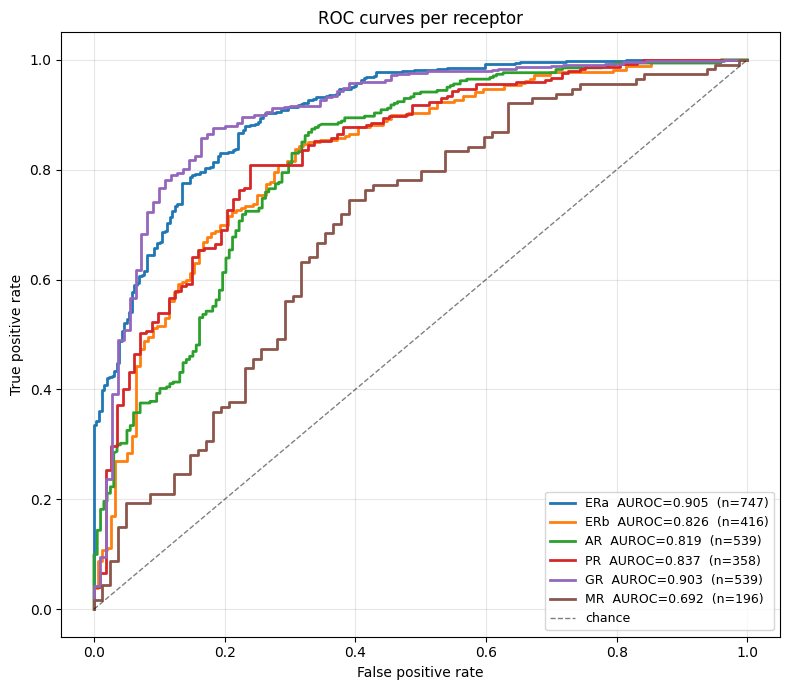

In [23]:
plt.figure(figsize=(8, 7))
for i, name in enumerate(TARGETS):
    mask = y[:, i] != -1
    if mask.sum() <= 10 or len(torch.unique(y[mask, i])) <= 1:
        continue
    y_true = y[mask, i].numpy()
    y_prob = probs[mask, i].numpy()
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name}  AUROC={auc:.3f}  (n={int(mask.sum())})")

plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves per receptor")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Cross-reactivity correlation matrix

For each test molecule the model emits six probabilities. The Pearson correlation across those six columns shows which receptors the model treats as "alike" from a ligand-chemistry standpoint. We expect the **NR3A block (ERα, ERβ)** and the **NR3C block (AR, PR, GR, MR)** to light up internally, with low correlation across blocks — the subfamily split recovered purely from learned chemistry.

<Figure size 700x600 with 0 Axes>

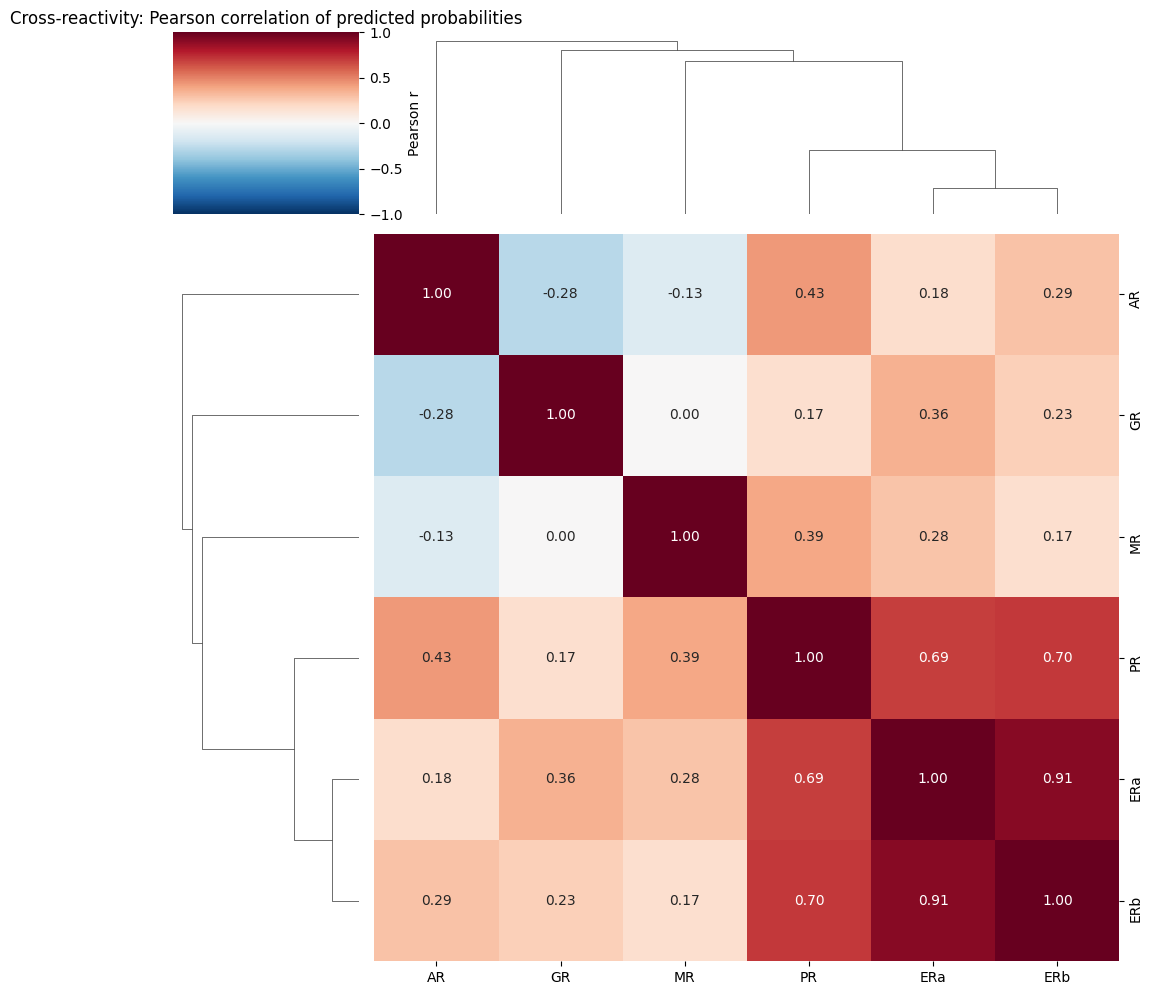

In [37]:
corr = pd.DataFrame(probs.numpy(), columns=TARGETS).corr()

plt.figure(figsize=(7, 6))
sns.clustermap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson r"},
)
plt.title("Cross-reactivity: Pearson correlation of predicted probabilities")
plt.tight_layout()
plt.show();

## 11. Visualize learned embeddings

t-SNE of the GCN graph embeddings, colored by which subfamily the molecule's binders belong to. ER ligands should cluster apart from the 3-ketosteroid ligands.

In [25]:
embeddings, labels_all = [], []
model.eval()
with torch.no_grad():
    for b in test_loader:
        b = b.to(device)
        _, emb = model(b)
        embeddings.append(emb.cpu())
        labels_all.append(b.y.cpu())
emb = torch.cat(embeddings).numpy()
y_np = torch.cat(labels_all).numpy()


# tag each molecule by which subfamily it hits
def subfamily_tag(row):
    er_hit = any(row[TARGETS.index(t)] == 1 for t in ["ERa", "ERb"])
    kt_hit = any(row[TARGETS.index(t)] == 1 for t in ["AR", "PR", "GR", "MR"])
    if er_hit and kt_hit:
        return "both"
    if er_hit:
        return "ER only"
    if kt_hit:
        return "3-ketosteroid only"
    return "no binder labeled"


tags = [subfamily_tag(r) for r in y_np]

coords = TSNE(
    n_components=2, perplexity=30, random_state=0, init="pca", learning_rate="auto"
).fit_transform(emb)

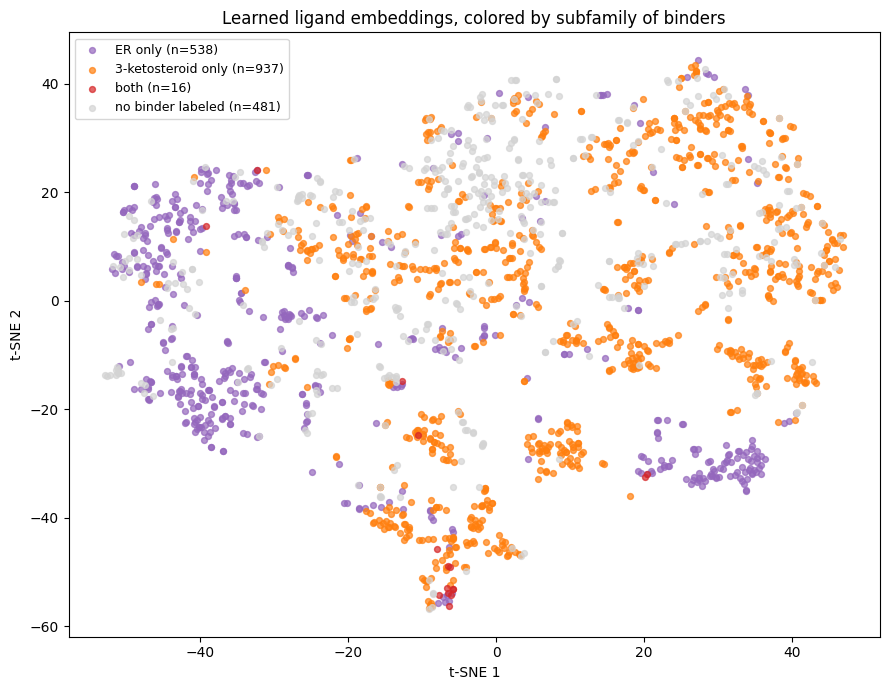

In [26]:
plt.figure(figsize=(9, 7))
order = ["ER only", "3-ketosteroid only", "both", "no binder labeled"]
colors = {
    "ER only": "tab:purple",
    "3-ketosteroid only": "tab:orange",
    "both": "tab:red",
    "no binder labeled": "lightgray",
}
for t in order:
    idx = [i for i, x in enumerate(tags) if x == t]
    if not idx:
        continue
    plt.scatter(
        coords[idx, 0], coords[idx, 1], label=f"{t} (n={len(idx)})", s=18, alpha=0.7, c=colors[t]
    )
plt.legend(loc="best", fontsize=9)
plt.title("Learned ligand embeddings, colored by subfamily of binders")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

The plot above collapses everything inside each subfamily. The README claims more structure within the 3-ketosteroid blob: AR ligands somewhat distinct (DHT-like), GR/MR strongly overlapping, PR in between. To check this, the panel below colors only **single-receptor binders** — molecules labeled as binding exactly one of the six receptors — one color per receptor.

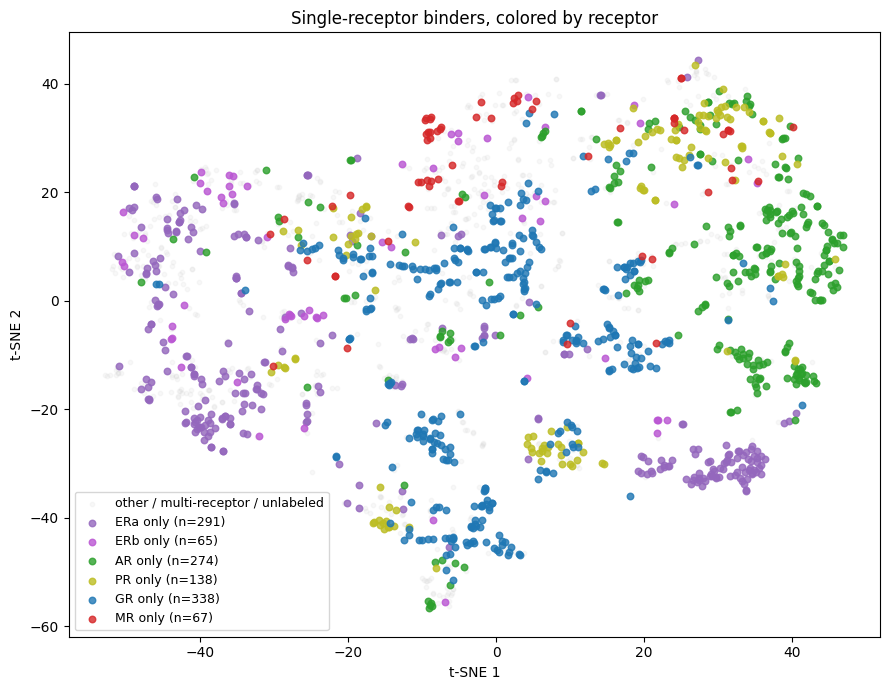

In [27]:
def single_receptor_tag(row):
    binders = [t for j, t in enumerate(TARGETS) if row[j] == 1]
    return binders[0] if len(binders) == 1 else None


single_tags = [single_receptor_tag(r) for r in y_np]

receptor_colors = {
    "ERa": "tab:purple",
    "ERb": "mediumorchid",
    "AR": "tab:green",
    "PR": "tab:olive",
    "GR": "tab:blue",
    "MR": "tab:red",
}

plt.figure(figsize=(9, 7))
# faint background of all points, so the colored ones sit in context
plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=10,
    alpha=0.15,
    c="lightgray",
    label="other / multi-receptor / unlabeled",
)
for t in TARGETS:
    idx = [i for i, x in enumerate(single_tags) if x == t]
    if not idx:
        continue
    plt.scatter(
        coords[idx, 0],
        coords[idx, 1],
        label=f"{t} only (n={len(idx)})",
        s=22,
        alpha=0.8,
        c=receptor_colors[t],
    )
plt.legend(loc="best", fontsize=9)
plt.title("Single-receptor binders, colored by receptor")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 12. Predict on canonical reference ligands

Now we predict on the canonical ligands themselves. Because we removed all close analogs (Tanimoto ≥ 0.7) before training, these predictions are out-of-sample. A model that has learned real chemistry should rank these sensibly.

In [28]:
list_activity = []
model.eval()
with torch.no_grad():
    for name, smi in canonical_ligand_dict.items():
        g = smiles_to_graph(smi, [-1] * len(TARGETS))
        if g is None:
            print(f"{name:16s}  (failed to parse)")
            continue
        g.batch = torch.zeros(g.x.size(0), dtype=torch.long)
        g = g.to(device)
        lg, _ = model(g)
        p = torch.sigmoid(lg).cpu().numpy().flatten()
        list_activity.append([name] + list(p))

# Display dataframe
pd.set_option("display.precision", 2)
pred_df = pd.DataFrame.from_records(list_activity)
pred_df.columns = ["ligand"] + TARGETS
pred_df = pred_df.set_index("ligand")
pred_df

,ERa,ERb,AR,PR,GR,MR
ligand,,,,,,
estradiol,9.76e-01,0.99,0.71,0.96,0.55,0.81
DHT,8.94e-01,0.96,0.94,0.81,0.02,0.62
testosterone,7.75e-01,0.91,0.86,0.79,0.06,0.74
progesterone,6.18e-01,0.81,0.78,0.73,0.13,0.83
cortisol,1.67e-02,0.13,0.46,0.61,0.65,0.58
aldosterone,1.22e-01,0.35,0.48,0.59,0.44,0.79
dexamethasone,5.39e-03,0.05,0.20,0.85,0.98,0.42
spironolactone,3.42e-01,0.46,0.64,0.66,0.58,0.84
eplerenone,1.57e-02,0.13,0.20,0.69,0.92,0.66


**How to read this table.** These numbers are the model's *ranking* of each ligand across the six receptors, not calibrated physical binding probabilities. The training objective was a binarized 1 µM cutoff, so the sigmoid output is a learned score for an ordinal binder / non-binder decision — *not* P(binds). Read each row left-to-right ("which receptors does this ligand prefer?") and compare relative magnitudes within a row; do not threshold at 0.5 and treat the result as a yes/no call. The same caveat applies to the clustermap below.

### Clustermap

Hierarchical clustering of canonical ligands and receptors. The dendrograms reveal whether the model has learned to group ligands by chemistry (estrogens vs. 3-ketosteroids) and receptors by pocket similarity (ERα/ERβ pair, GR/MR/PR cluster).

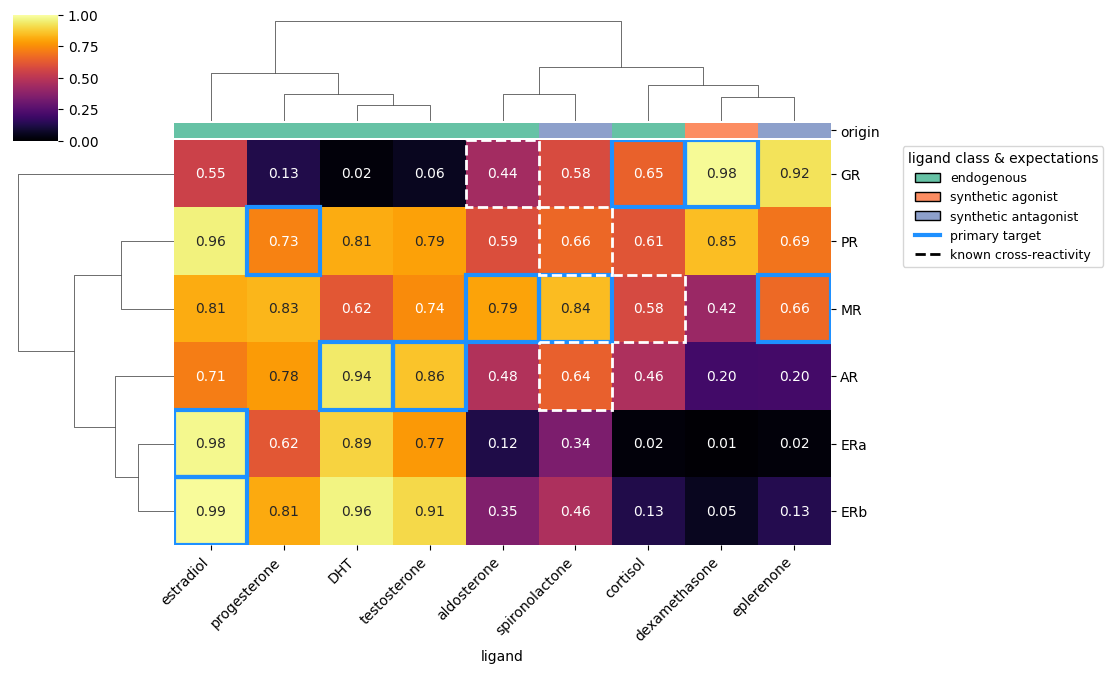

In [39]:
# Define expected binding for each ligand.
# Tuple: (primary targets, secondary/cross-reactive targets)
expected = {
    "estradiol": (["ERa", "ERb"], []),
    "DHT": (["AR"], []),
    "testosterone": (["AR"], []),
    "progesterone": (["PR"], []),
    "cortisol": (["GR"], ["MR"]),  # cortisol binds MR strongly too
    "dexamethasone": (["GR"], []),
    "aldosterone": (["MR"], ["GR"]),  # in vitro aldosterone hits GR too
    "spironolactone": (["MR"], ["AR", "PR"]),  # known clinical cross-reactivity
    "eplerenone": (["MR"], []),
}

origin = {
    "estradiol": "endogenous",
    "DHT": "endogenous",
    "testosterone": "endogenous",
    "progesterone": "endogenous",
    "cortisol": "endogenous",
    "aldosterone": "endogenous",
    "dexamethasone": "synthetic agonist",
    "spironolactone": "synthetic antagonist",
    "eplerenone": "synthetic antagonist",
}

origin_colors = {
    "endogenous": sns.color_palette("Set2")[0],
    "synthetic agonist": sns.color_palette("Set2")[1],
    "synthetic antagonist": sns.color_palette("Set2")[2],
}


# col_colors must be a pandas Series aligned with the heatmap columns
col_colors = pd.DataFrame(
    {
        "origin": pred_df.index.map(lambda lut: origin_colors[origin[lut]]),
    },
    index=pred_df.index,
)


g = sns.clustermap(
    pred_df.T,
    cmap="inferno",
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    col_colors=col_colors,
    figsize=(9, 7),
)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")  # For x axis
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)  # For y axis

# After clustering, rows and columns are reordered. Look up the new positions.
reordered_receptors = [pred_df.T.index[i] for i in g.dendrogram_row.reordered_ind]
reordered_ligands = [pred_df.T.columns[i] for i in g.dendrogram_col.reordered_ind]

ax = g.ax_heatmap
for ligand, (primary, secondary) in expected.items():
    if ligand not in reordered_ligands:
        continue
    col = reordered_ligands.index(ligand)
    for receptor in primary:
        if receptor in reordered_receptors:
            row = reordered_receptors.index(receptor)
            ax.add_patch(
                patches.Rectangle(
                    (col, row),
                    1,
                    1,
                    fill=False,
                    edgecolor="dodgerblue",
                    lw=3,
                    zorder=10,
                )
            )
    for receptor in secondary:
        if receptor in reordered_receptors:
            row = reordered_receptors.index(receptor)
            ax.add_patch(
                patches.Rectangle(
                    (col, row),
                    1,
                    1,
                    fill=False,
                    edgecolor="white",
                    lw=2,
                    linestyle="--",
                    zorder=10,
                )
            )

class_handles = [
    patches.Patch(facecolor=color, edgecolor="black", label=cls)
    for cls, color in origin_colors.items()
]
# Add a small legend
legend_elements = [
    Line2D([0], [0], color="dodgerblue", lw=3, label="primary target"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="known cross-reactivity"),
]

g.ax_heatmap.legend(
    handles=class_handles + legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.1, 1.0),
    frameon=True,
    fontsize=9,
    title="ligand class & expectations",
)
plt.show()

## 13. How much does prediction quality depend on having close training neighbours?

For each canonical ligand, we compute the Tanimoto similarity to its nearest neighbour in the training set. Because we removed everything ≥ 0.7, the maximum possible value is just under 0.7.

The scatter plot below puts each canonical ligand at (max Tanimoto in train, predicted probability on its primary correct receptor). Points in the **top-left** are real generalization — the model gets the prediction right despite having no close neighbours. Points in the **top-right** are "easy" predictions where there were near-relatives in training.

In [30]:
# fingerprints of the training set
train_fps = [(s, fp(s)) for s in train_smiles]
train_fps = [(s, f) for s, f in train_fps if f is not None]
print(f"computed {len(train_fps)} training fingerprints")

computed 9493 training fingerprints


In [31]:
# ligand → primary correct receptor (the one we expect highest activity on).
# Derived from `expected` defined in section 12, so the two stay in sync.
correct_target = {ligand: targets[0][0] for ligand, targets in expected.items()}

diag_rows = []
for name, smi in canonical_ligand_dict.items():
    q = fp(smi)
    if q is None:
        continue
    sims = [DataStructs.TanimotoSimilarity(q, f) for _, f in train_fps]
    best_i = int(np.argmax(sims))
    max_tan = sims[best_i]
    nearest_smi = train_fps[best_i][0]
    pred_correct = pred_df.loc[name, correct_target[name]]
    diag_rows.append(
        {
            "ligand": name,
            "primary_target": correct_target[name],
            "max_tanimoto_train": max_tan,
            "pred_on_primary": pred_correct,
            "nearest_train_smi": nearest_smi,
        }
    )

diag = pd.DataFrame(diag_rows)
diag

,ligand,primary_target,max_tanimoto_train,pred_on_primary,nearest_train_smi
0,estradiol,ERa,0.67,0.98,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1[C@@...
1,DHT,AR,0.54,0.94,C[C@]12CCC(=O)C[C@@H]1C[C@@H](CCCCCCCC(=O)O)[C...
2,testosterone,AR,0.69,0.86,C=C[C@]12CCC(=O)C=C1CCC1C2CC[C@@]2(C)C1CC[C@@H]2O
3,progesterone,PR,0.69,0.73,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
4,cortisol,GR,0.70,0.65,CCC(=O)O[C@]1(C(=O)CO)CC[C@H]2[C@@H]3CCC4=CC(=...
5,aldosterone,MR,0.63,0.79,CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
6,dexamethasone,GR,0.68,0.98,C[C@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@...
7,spironolactone,MR,0.49,0.84,COC(=O)[C@@H]1CC2=CC(=O)CC[C@]2(C)C2C1C1CC[C@@...
8,eplerenone,MR,0.53,0.66,COC(=O)[C@@H]1CC2=CC(=O)CC[C@]2(C)C2C1C1CC[C@@...


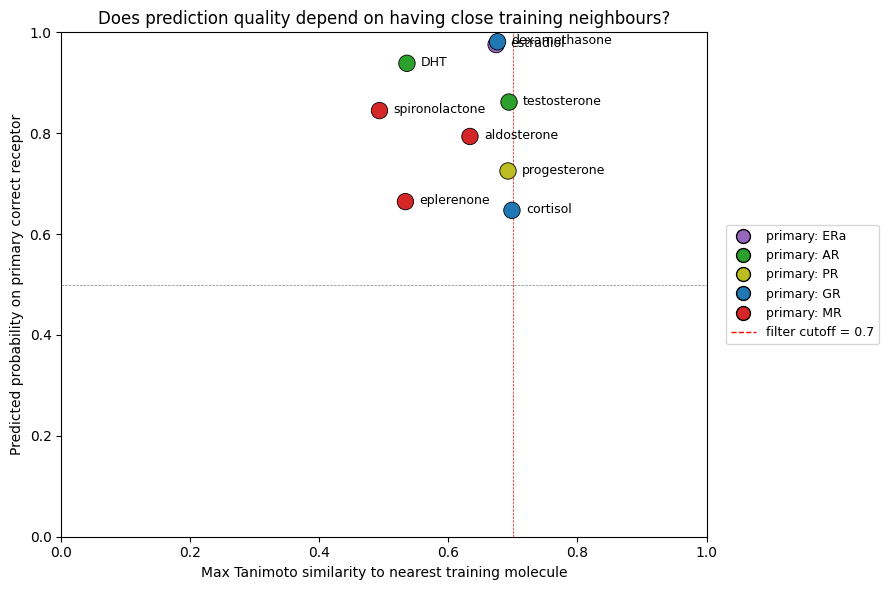

In [32]:
# color by primary target receptor
target_colors = {
    "ERa": "tab:purple",
    "ERb": "mediumorchid",
    "AR": "tab:green",
    "PR": "tab:olive",
    "GR": "tab:blue",
    "MR": "tab:red",
}
colors = [target_colors[t] for t in diag["primary_target"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    diag["max_tanimoto_train"],
    diag["pred_on_primary"],
    c=colors,
    s=140,
    edgecolors="black",
    linewidths=0.6,
    zorder=3,
)

for _, row in diag.iterrows():
    ax.annotate(
        row["ligand"],
        (row["max_tanimoto_train"], row["pred_on_primary"]),
        xytext=(10, -2),
        textcoords="offset points",
        fontsize=9,
    )

ax.axhline(0.5, color="gray", lw=0.5, linestyle="--")
ax.axvline(
    SIMILARITY_THRESHOLD,
    color="red",
    lw=0.5,
    linestyle="--",
    label=f"filter cutoff (Tanimoto = {SIMILARITY_THRESHOLD})",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Max Tanimoto similarity to nearest training molecule")
ax.set_ylabel("Predicted probability on primary correct receptor")
ax.set_title("Does prediction quality depend on having close training neighbours?")

# build legend: one entry per receptor that appears, plus the cutoff line
present_targets = diag["primary_target"].unique().tolist()
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=target_colors[t],
        markeredgecolor="black",
        markersize=10,
        label=f"primary: {t}",
    )
    for t in TARGETS
    if t in present_targets
]
legend_elements.append(
    Line2D(
        [0], [0], color="red", lw=1, linestyle="--", label=f"filter cutoff = {SIMILARITY_THRESHOLD}"
    )
)
ax.legend(
    handles=legend_elements, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=9
)

plt.tight_layout()
plt.show()

In summary, variation in prediction quality is explained by which receptor the ligand targets, not by how similar it is to training data